In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_style(style="whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv(r'C:\Users\Gene\Downloads\Employees.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (28, 10)


,employee_id,organisation_id,branch_id,department_id,employee_reference,year_of_birth,sex,employment_type,status,created_at
0,EMP-001,ORG-001,BR-001,DEP-001,KMG-0001,1976,male,permanent,active,2026-05-20T08:00:00Z
1,EMP-002,ORG-001,BR-001,DEP-002,KMG-0002,1990,female,permanent,active,2026-05-20T08:00:00Z
2,EMP-003,ORG-001,BR-001,DEP-003,KMG-0003,1979,male,permanent,active,2026-05-20T08:00:00Z
3,EMP-004,ORG-001,BR-001,DEP-004,KMG-0004,1980,female,permanent,active,2026-05-20T08:00:00Z
4,EMP-005,ORG-001,BR-001,DEP-001,KMG-0005,2001,male,permanent,active,2026-05-20T08:00:00Z
5,EMP-006,ORG-001,BR-001,DEP-002,KMG-0006,1986,female,contract,active,2026-05-20T08:00:00Z
6,EMP-007,ORG-001,BR-001,DEP-003,KMG-0007,1998,male,contract,active,2026-05-20T08:00:00Z
7,EMP-008,ORG-001,BR-001,DEP-004,KMG-0008,1986,female,permanent,active,2026-05-20T08:00:00Z
8,EMP-009,ORG-001,BR-001,DEP-001,KMG-0009,1978,male,contract,active,2026-05-20T08:00:00Z
9,EMP-010,ORG-001,BR-001,DEP-002,KMG-0010,1984,female,contract,active,2026-05-20T08:00:00Z


## 1. Structural inspection
Checking dtypes to see if the data makes sense

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   employee_id         28 non-null     str  
 1   organisation_id     28 non-null     str  
 2   branch_id           28 non-null     str  
 3   department_id       28 non-null     str  
 4   employee_reference  28 non-null     str  
 5   year_of_birth       28 non-null     int64
 6   sex                 28 non-null     str  
 7   employment_type     28 non-null     str  
 8   status              28 non-null     str  
 9   created_at          28 non-null     str  
dtypes: int64(1), str(9)
memory usage: 4.4 KB


## 2. Grain integrity check
Testing for two identifiers
1. 'employee_id'; the primary key
2. 'employee_reference'; secondary code. Checking that it's unique and that it follows a consistent format 

In [31]:
# Primary key uniqueness check
n_rows = len(df)
assert n_rows == df['employee_id'].nunique(), "employee_id is NOT a clean primary key"
print(f"PASS: employee_id is a clean primary key across {n_rows} unique values.")

# Secondary key uniqueness check
assert n_rows == df['employee_reference'].nunique(), "employee_reference has duplicates"
print(f"PASS: employee_reference is unique.")

# Format consistency check
pattern_ok = df['employee_reference'].str.match(r'^KMG-\d{4}$')
print(f"employee_reference rows matching expected 'KMG-####' format: {pattern_ok.sum()} / {n_rows} ({pattern_ok.mean():.2%})")
if not pattern_ok.all():
    print("FLAG: Some employee_reference values do not match the expected format.")
    display(df[~pattern_ok])
else:
    print("PASS: All employee_reference values match the expected format.")

PASS: employee_id is a clean primary key across 28 unique values.
PASS: employee_reference is unique.
employee_reference rows matching expected 'KMG-####' format: 28 / 28 (100.00%)
PASS: All employee_reference values match the expected format.


## 3. Missingness analysis


employee_id           0
organisation_id       0
branch_id             0
department_id         0
employee_reference    0
year_of_birth         0
sex                   0
employment_type       0
status                0
created_at            0
dtype: int64



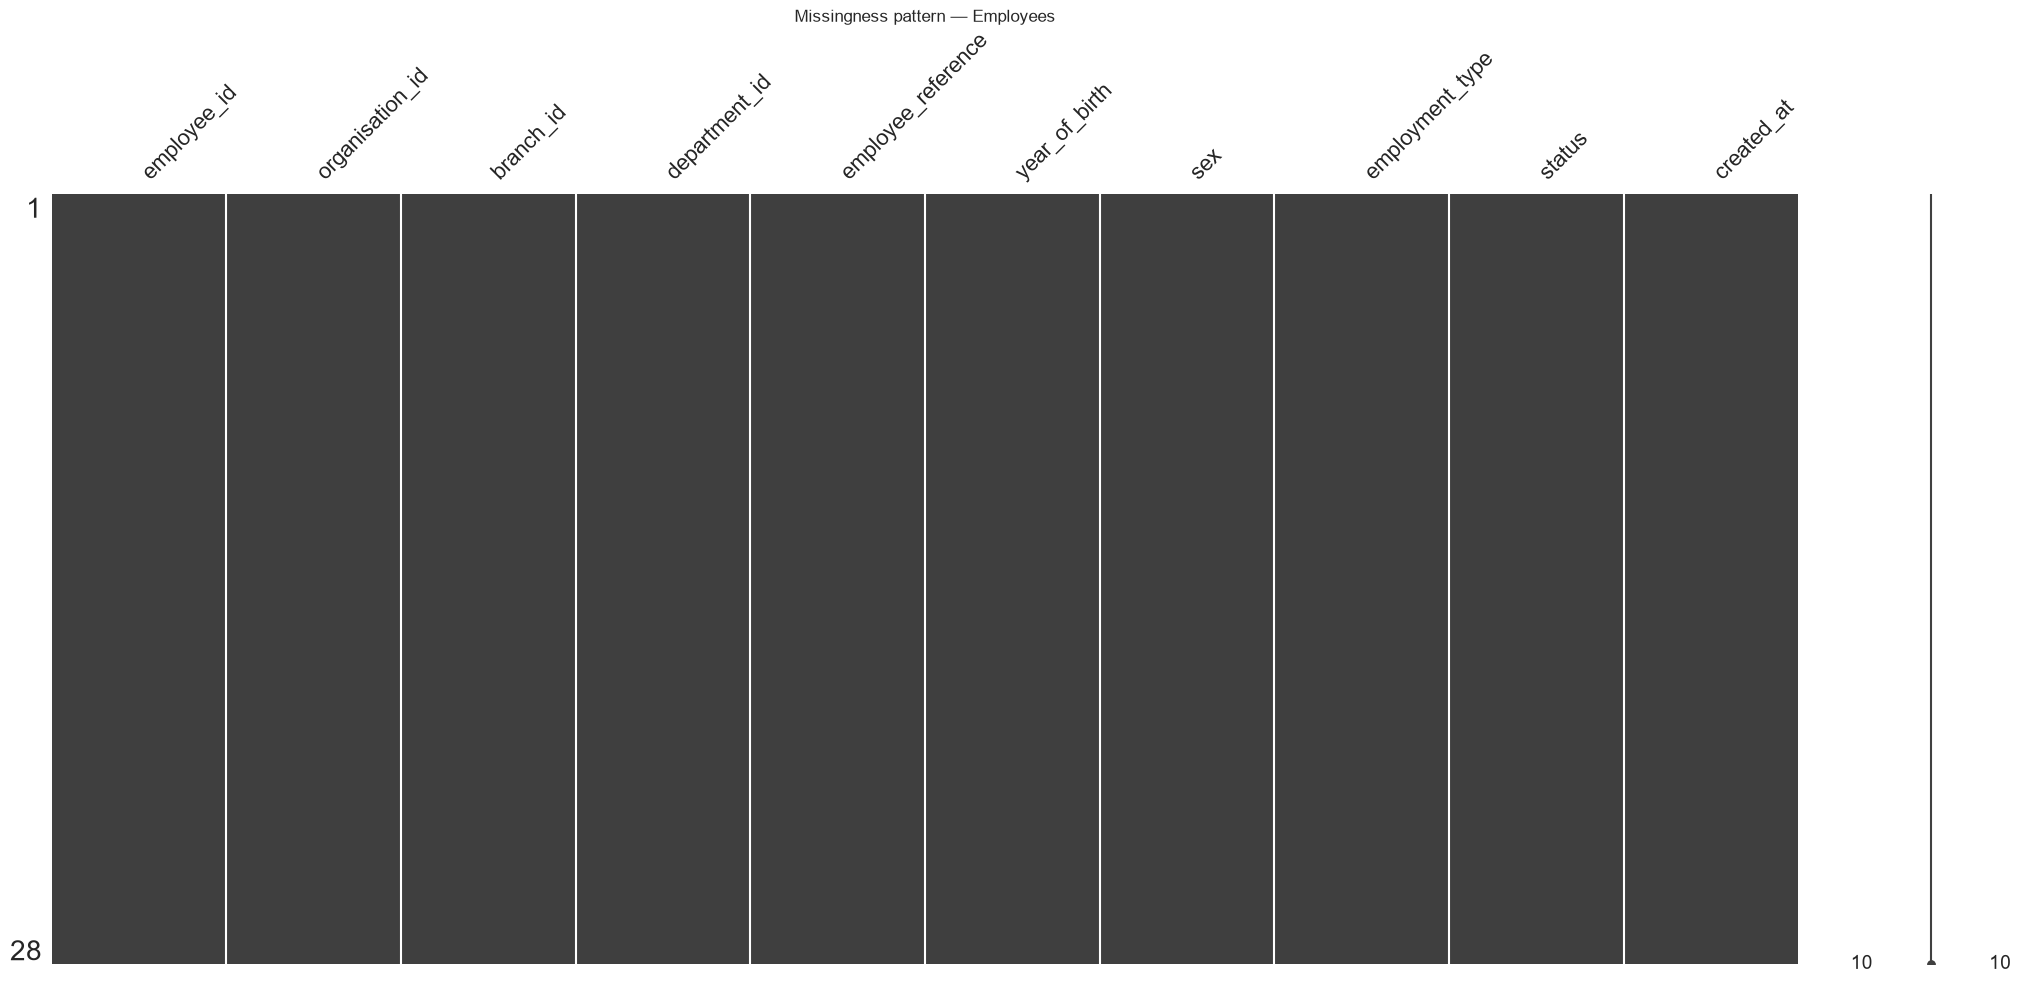

In [32]:
print(df.isna().sum())
print()
msno.matrix(df)
plt.title('Missingness pattern — Employees')
plt.show()

## 4. Categorical distributions


--- organisation_id ---
organisation_id
ORG-001    28
Name: count, dtype: int64 

--- branch_id ---
branch_id
BR-001    19
BR-002     9
Name: count, dtype: int64 

--- department_id ---
department_id
DEP-001    7
DEP-002    7
DEP-003    7
DEP-004    7
Name: count, dtype: int64 

--- sex ---
sex
male      14
female    14
Name: count, dtype: int64 

--- status ---
status
active    28
Name: count, dtype: int64 

--- employment_type ---
employment_type
permanent    19
contract      9
Name: count, dtype: int64 



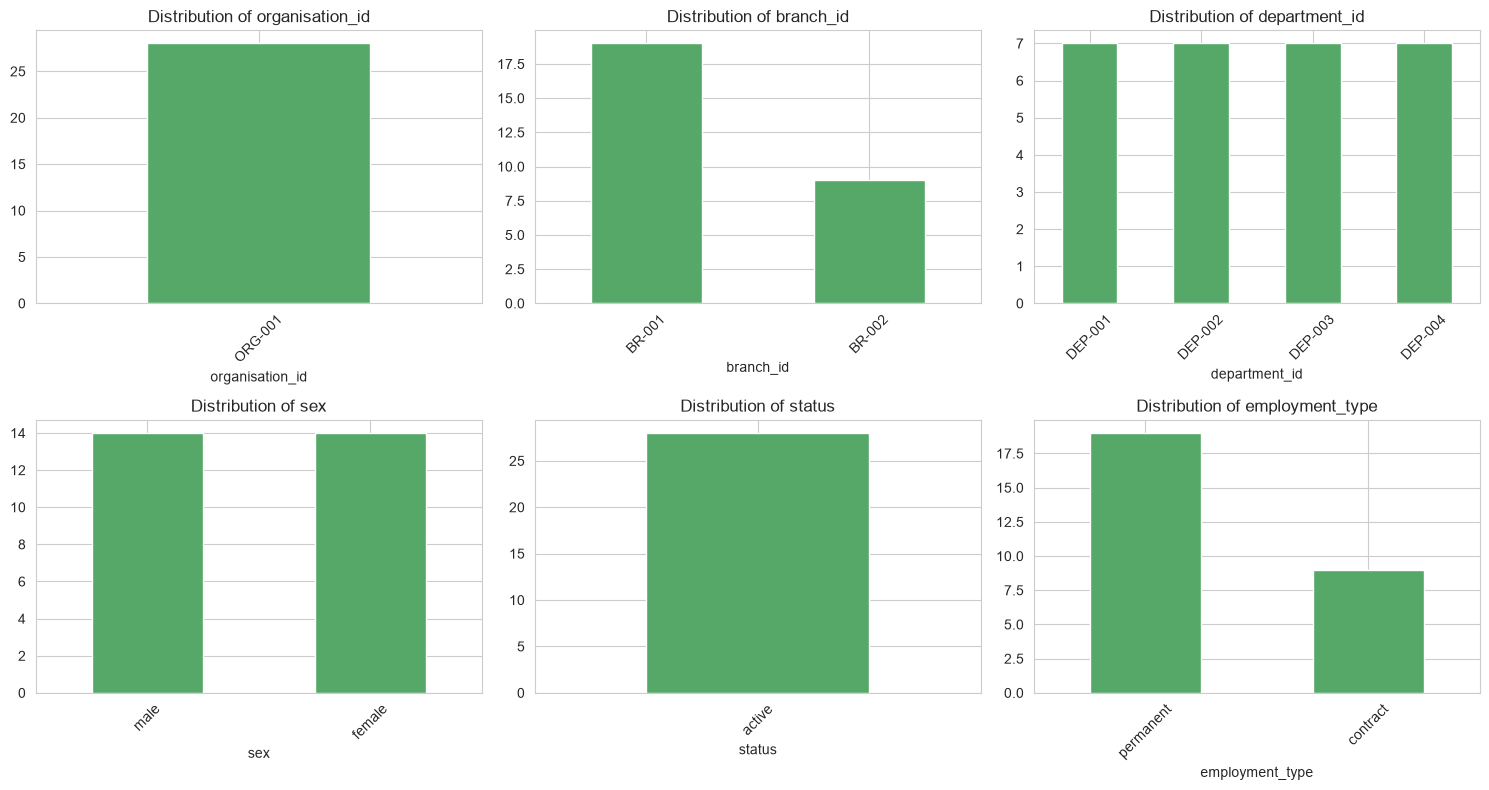

In [33]:
cat_cols = ['organisation_id', 'branch_id', 'department_id', 'sex', 'status', 'employment_type']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    print(f"--- {col} ---")
    print(counts, "\n")
    counts.plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Observations to flag:**
`organisation_id` (all `ORG-001`) and `status` (all `active`) show zero variance in this sample. That means this notebook **cannot** validate multi-organisation behaviour, or how the pipeline handles an inactive/terminated employee. Both are real scenarios the production data will eventually contain, and any downstream logic built only against this sample risks being untested for them.

## 5. Cross-tabulations, structural sanity checks
 Checking if `department_id` is consistent in meaning across branches, or is it branch-scoped? This matters a lot for any future groupby. If `DEP-001` means something different in `BR-001` vs `BR-002`, aggregating by `department_id` alone would silently mix unrelated things.

In [34]:
branch_dept = pd.crosstab(df['branch_id'], df['department_id'])
print(branch_dept)
print()
print("Every department_id appears under every branch_id here, which is consistent with department_id",
      "being a shared org-wide classification rather than branch-scoped. Worth confirming with the",
      "handbook or schema owner rather than assuming from 28 rows.")

department_id  DEP-001  DEP-002  DEP-003  DEP-004
branch_id                                        
BR-001               5        5        5        4
BR-002               2        2        2        3

Every department_id appears under every branch_id here, which is consistent with department_id being a shared org-wide classification rather than branch-scoped. Worth confirming with the handbook or schema owner rather than assuming from 28 rows.


## 6. Derived field: employee age, with a plausibility check
Sanity checking the derived age values against a plausible working-age range rather than assuming the arithmetic is automatically meaningful.

count    28.000000
mean     41.107143
std      10.489287
min      25.000000
25%      30.500000
50%      41.500000
75%      47.250000
max      58.000000
Name: age, dtype: float64

Rows with implausible age values: 0
PASS: All age values are within the plausible range of 18 to 100.


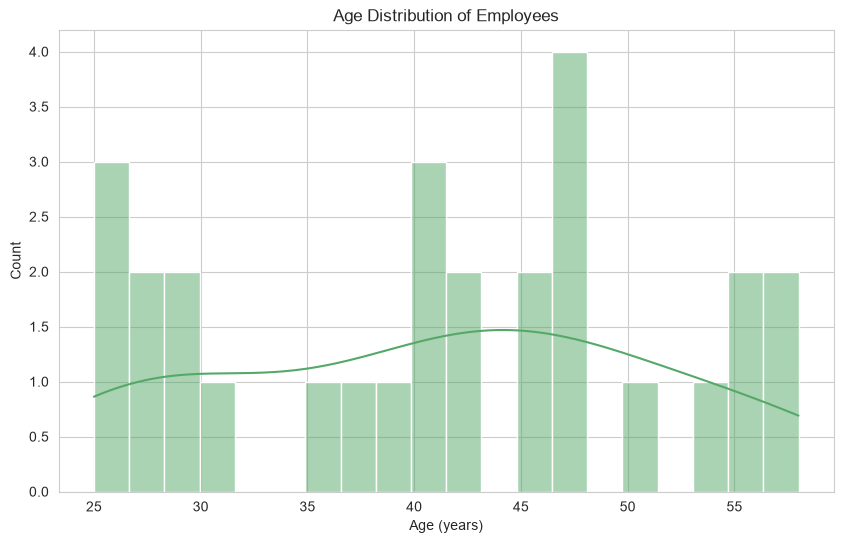

In [35]:
REFERENCE_YEAR = 2026
df['age'] = REFERENCE_YEAR - df['year_of_birth']

print(df['age'].describe())
# Plausibility check: age should be between 18 and 100
implausible_age = df[(df['age'] < 18) | (df['age'] > 100)]
print(f"\nRows with implausible age values: {len(implausible_age)}")
if len(implausible_age) > 0:
    display(implausible_age)
else:
    print("PASS: All age values are within the plausible range of 18 to 100.")

plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True, color='#55A868')
plt.title('Age Distribution of Employees')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.show()

## 7. Referential integrity: Employees ↔ Participations
Does every 'employee_id' in 'Participations' resolve to a real row in 'Employees', and vice versa? 

In [36]:
par = pd.read_csv(r"C:\Users\Gene\Downloads\Pulse80\Participations.csv")

emp_ids = set(df['employee_id'])
par_ids = set(par['employee_id'])

orphaned_par_ids = par_ids - emp_ids # participation rows referencing an employee that doesn't exist
never_participated_emp_ids = emp_ids - par_ids # employees that have never participated

print(f"Participation employee_id values not found in Employees: {len(orphaned_par_ids)}")
if orphaned_par_ids:
    print(sorted(orphaned_par_ids))

print(f"\nEmployees that have never participated: {len(never_participated_emp_ids)}")
if never_participated_emp_ids:
    print(sorted(never_participated_emp_ids))
    
if not orphaned_par_ids and not never_participated_emp_ids:
    print("\nPASS: All employee_id values in Participations are valid and all employees have participated at least once.")  

Participation employee_id values not found in Employees: 0

Employees that have never participated: 0

PASS: All employee_id values in Participations are valid and all employees have participated at least once.


**Note:** this file happens to contain exactly the 28 employees who all participate in `PRG-001`, so a perfect match here is expected given how the sample was constructed. It's not yet evidence that referential integrity will hold once more programmes and a larger employee population are loaded. Re-run this exact check once fuller data is available; the code doesn't need to change, only the inputs.

## 8. Summary

- **Grain:** `employee_id` is a clean, unique primary key. `employee_reference` is unique and consistently formatted as `KMG-####`.
- **Missingness:** none, every column is fully populated across all 28 rows.
- **Categorical coverage limitation:** `organisation_id` (all `ORG-001`) and `status` (all `active`) show no variance in this sample, multi-org and inactive-employee behaviour are **not yet validated**.
- **Structural check:** `department_id` values appear consistently across both branches, consistent with department being an org-wide classification rather than branch-scoped (worth confirming against the schema/handbook rather than relying on 28 rows).
- **Derived field:** employee age (from `year_of_birth`) falls within a plausible working-age range for every row.
- **Referential integrity:** every `employee_id` in `Participations` matches an `Employees` row, and every employee here has a participation record, however this is expected given how the sample was built, not proof the relationship holds at scale.

## 9. Recommended next steps

1. Re-run Section 7's referential integrity check once `Measurements` and `Risk_Assessments` can also be joined through the still-missing `Programmes` table. The goal is one referential integrity notebook covering the full chain: Employees → Participations → Programmes → Screenings.
2. Once multi-organisation or inactive-employee data is available, re-run Sections 4 and 5. This sample cannot currently validate either scenario.
3. Confirm whether `department_id` is genuinely org-wide (as this sample suggests) or branch-scoped, before using it as a groupby key in any dashboard.
4. Treat Section 7 as a template for a lightweight pipeline test. It's a strong candidate to become an actual automated check (e.g. a dbt test or a CI assertion) rather than staying a manual notebook step.